In [2]:
import pandas as pd
data = pd.read_csv("raw data.csv")
print(data.head())

   order_delivery_date_id  source_order_header_id  source_member_id  \
0                20251126              1837962888          16265039   
1                20251121              1828973146          11488782   
2                20251125              1837360421          21806809   
3                20251106              1821995270           6143232   
4                20251130              1841246009           1733139   

     source_city_name         location_name source_location_type payment_type  \
0             Gurgaon    DS-BNGUR-Sector-85              LT-IBBN     NEUCOINS   
1  Chandigarh Tricity  DS-IBMOH-ISBT Ludhia                 IBBN          PAY   
2           Bangalore  DS-IBBLR-BrigadeRoad                 IBBN       UPI_QR   
3           Bangalore      DS-IBBLR-Manyata              LT-IBBN          PAY   
4           Hyderabad      DS-IBHYD-Tarnaka                 IBBN         VISA   

   member_id source_slug member_class  member_state evoucher_code  \
0   16697711     

In [3]:
data.describe()

,order_delivery_date_id,source_order_header_id,source_member_id,member_id,order_count,qty,total_sales,refund_amount,refund_orders
count,1.340600e+04,1.340600e+04,1.340600e+04,1.340600e+04,13406.0,13406.000000,13406.000000,13406.000000,13406.000000
mean,2.025112e+07,1.829284e+09,3.596340e+07,3.901126e+07,1.0,5.998241,465.746561,6.066213,0.036700
std,8.768500e+00,7.111638e+06,2.134489e+07,2.635555e+07,0.0,5.334443,1283.339519,62.176922,0.220193
min,2.025110e+07,1.814529e+09,9.540000e+02,1.800000e+02,1.0,0.060000,0.600000,0.000000,0.000000
25%,2.025111e+07,1.823330e+09,1.781538e+07,1.790373e+07,1.0,2.000000,183.925000,0.000000,0.000000
50%,2.025112e+07,1.829204e+09,3.429250e+07,3.502277e+07,1.0,5.000000,278.225000,0.000000,0.000000
75%,2.025112e+07,1.835427e+09,5.458406e+07,5.528545e+07,1.0,8.000000,502.957500,0.000000,0.000000
max,2.025113e+07,1.841619e+09,7.732749e+07,1.186287e+08,1.0,94.000000,99990.000000,3189.000000,6.000000


In [4]:
data.nunique()


order_delivery_date_id       30
source_order_header_id    13406
source_member_id          13120
source_city_name             50
location_name               819
source_location_type          6
payment_type                 22
member_id                 13120
source_slug                   7
member_class                  1
member_state                  1
evoucher_code               448
order_count                   1
qty                        1116
total_sales                8887
last_order_date              30
refund_amount               335
refund_orders                 6
delivery_date                30
dtype: int64

In [5]:
data.shape

(13406, 19)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13406 entries, 0 to 13405
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_delivery_date_id  13406 non-null  int64  
 1   source_order_header_id  13406 non-null  int64  
 2   source_member_id        13406 non-null  int64  
 3   source_city_name        13406 non-null  object 
 4   location_name           13406 non-null  object 
 5   source_location_type    13406 non-null  object 
 6   payment_type            13406 non-null  object 
 7   member_id               13406 non-null  int64  
 8   source_slug             13406 non-null  object 
 9   member_class            13406 non-null  object 
 10  member_state            13406 non-null  object 
 11  evoucher_code           13406 non-null  object 
 12  order_count             13406 non-null  int64  
 13  qty                     13406 non-null  float64
 14  total_sales             13406 non-null

In [7]:
data.columns

Index(['order_delivery_date_id', 'source_order_header_id', 'source_member_id',
       'source_city_name', 'location_name', 'source_location_type',
       'payment_type', 'member_id', 'source_slug', 'member_class',
       'member_state', 'evoucher_code', 'order_count', 'qty', 'total_sales',
       'last_order_date', 'refund_amount', 'refund_orders', 'delivery_date'],
      dtype='object')

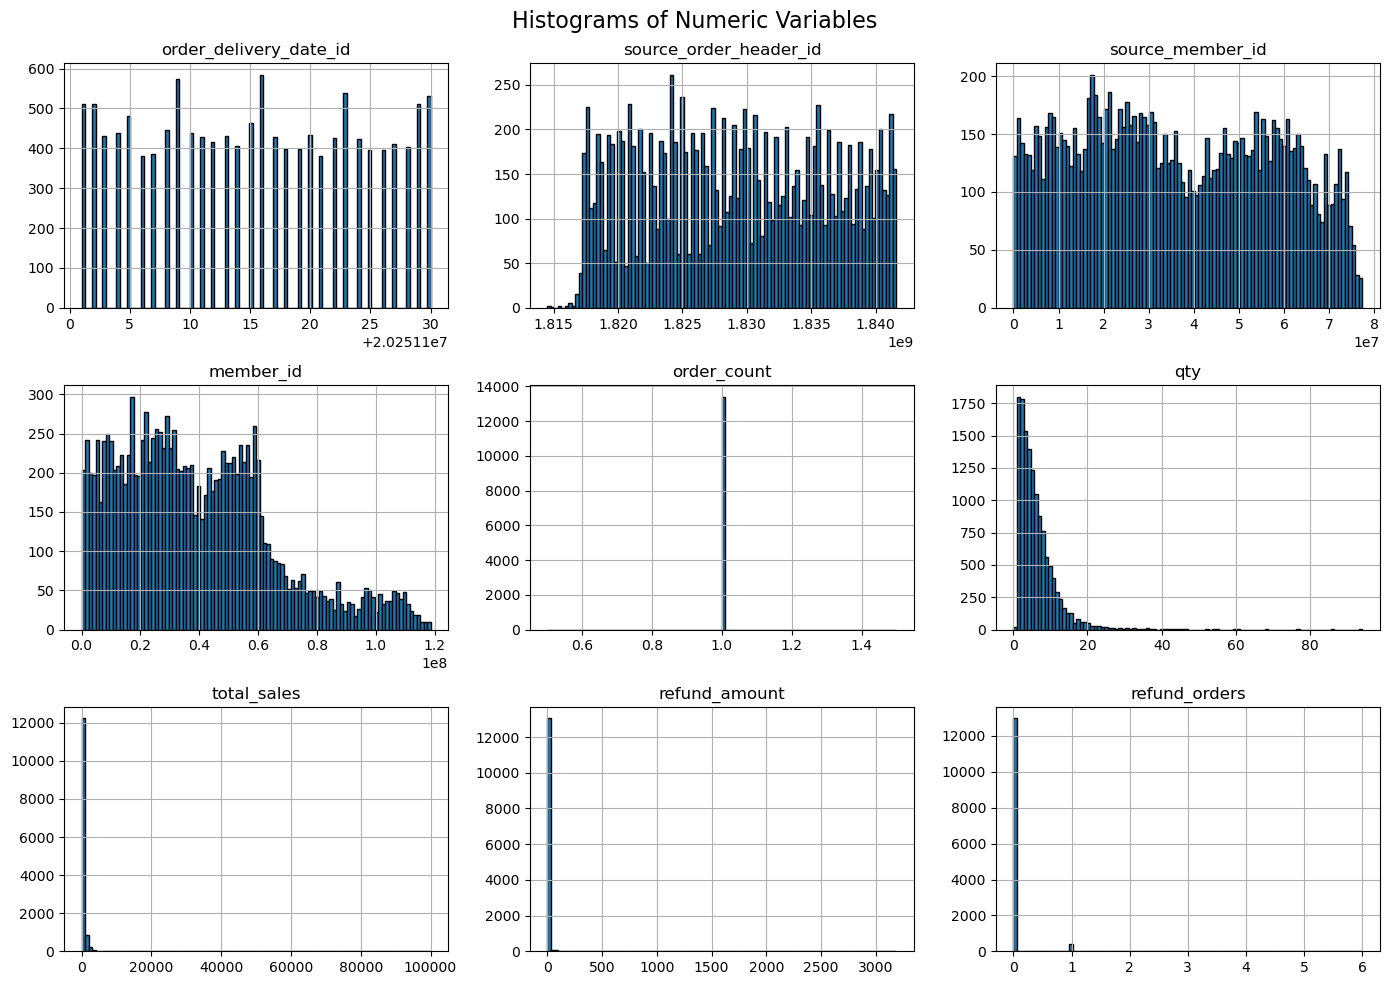

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include="number").columns
#num_cols

data[num_cols].hist(
    figsize=(14, 10),
    bins=100,
    edgecolor="black"
)

plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()


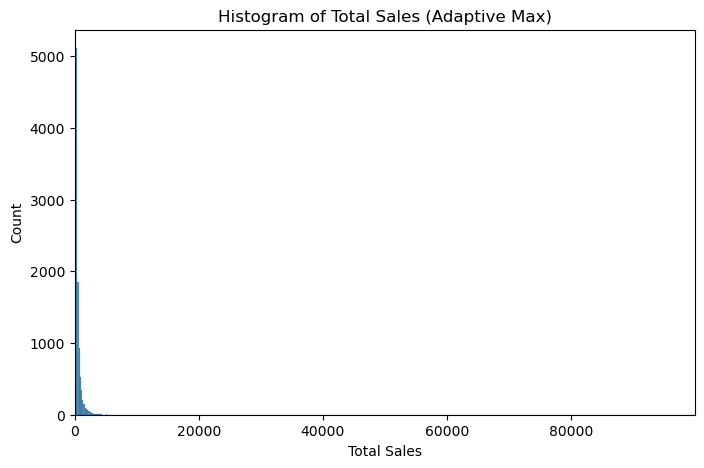

In [16]:

max_val = data["total_sales"].max()

plt.figure(figsize=(8, 5))
sns.histplot(
    data["total_sales"], 
    bins=500,              
    edgecolor="black"
)
plt.xlim(0, max_val)      
plt.title("Histogram of Total Sales (Adaptive Max)")
plt.xlabel("Total Sales")
plt.ylabel("Count")
plt.show()



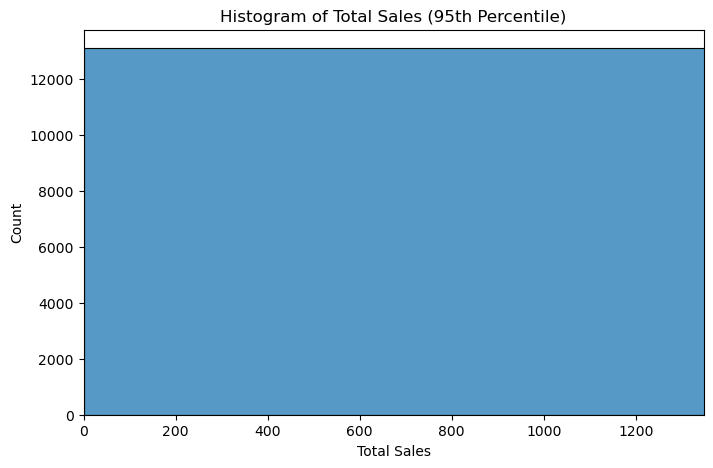

In [19]:

max_val_95 = data["total_sales"].quantile(0.95)

plt.figure(figsize=(8, 5))
sns.histplot(data["total_sales"], bins=50, edgecolor="black")
plt.xlim(0, max_val_95)  
plt.title("Histogram of Total Sales (95th Percentile)")
plt.xlabel("Total Sales")
plt.ylabel("Count")
plt.show()


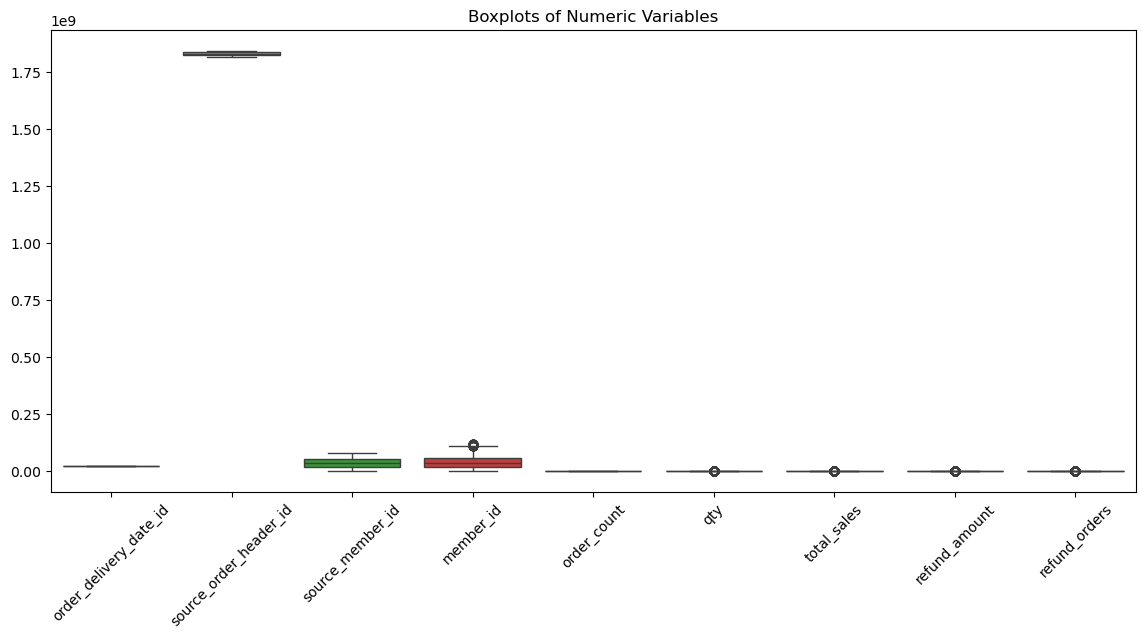

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Variables")
plt.show()
